<a href="https://colab.research.google.com/github/drohal3/computer_vision/blob/main/notebooks/yolo_train_custom_dataset_potholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download pothole dataset for training YOLO11

In [ ]:
!mkdir -p dataset
!curl -L "https://public.roboflow.com/ds/FnRTArlaqN?key=nxc3yjt24T" -o dataset/roboflow.zip
!unzip dataset/roboflow.zip -d dataset
!rm dataset/roboflow.zip
# remove original data.yaml file
!rm dataset/data.yaml

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   904  100   904    0     0   3224      0 --:--:-- --:--:-- --:--:--  3217
100 45.9M  100 45.9M    0     0  31.4M      0  0:00:01  0:00:01 --:--:-- 78.4M
Archive:  dataset/roboflow.zip
  inflating: dataset/README.dataset.txt  
  inflating: dataset/README.roboflow.txt  
  inflating: dataset/data.yaml       
   creating: dataset/test/
   creating: dataset/test/images/
 extracting: dataset/test/images/img-105_jpg.rf.3fe9dff3d1631e79ecb480ff403bcb86.jpg  
 extracting: dataset/test/images/img-107_jpg.rf.2e40485785f6e5e2efec404301b235c2.jpg  
 extracting: dataset/test/images/img-146_jpg.rf.61be25b3053a51f622a244980545df2b.jpg  
 extracting: dataset/test/images/img-161_jpg.rf.211541e7178a4a93ec0680f26b905427.jpg  
 extracting: dataset/test/images/img-168_jpg.rf.af3590e07b06b43e91fa53990ff94af3.jpg  
 extracting: dataset/test/images/i

Configure dataset.yaml

In [ ]:
yaml_content = """
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 1
names: ['pothole']
"""

with open("dataset/data.yaml", "w") as f:
    f.write(yaml_content)

Let's make sure that we have access to GPU. We can use nvidia-smi command to do that. In case of any problems navigate to Edit -> Notebook settings -> Hardware accelerator, set it to GPU, and then click Save.

In [ ]:
!nvidia-smi

Wed Aug  6 21:17:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Install ultralytics (contains YOLO)

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 111.6 MB/s eta 0:00:00


Train YOLO model on custom dataset

In [ ]:
import ultralytics

model = ultralytics.YOLO('yolo11n.pt')

# Train the model on the pothole dataset
results = model.train(data="dataset/data.yaml", epochs=10, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, prof

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

 18            [-1, 13]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 19                  -1  1     86720  ultralytics.nn.modules.block.C3k2            [192, 128, 1, False]          
 20                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 21            [-1, 10]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 22                  -1  1    378880  ultralytics.nn.modules.block.C3k2            [384, 256, 1, True]           
 23        [16, 19, 22]  1    430867  ultralytics.nn.modules.head.Detect           [1, [64, 128, 256]]           
YOLO11n summary: 181 layers, 2,590,035 parameters, 2,590,019 gradients, 6.4 GFLOPs

Transferred 448/499 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 18.0±10.3 MB

train: Scanning /content/dataset/train/labels... 465 images, 0 backgrounds, 0 corrupt: 100%|██████████| 465/465 [00:00<00:00, 622.60it/s]

...

      10/10      2.83G      1.289      1.468      1.287          1        640: 100%|██████████| 30/30 [00:08<00:00,  3.55it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:00<00:00,  5.42it/s]

                   all        133        330      0.768      0.633      0.712      0.413



10 epochs completed in 0.028 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  2.06it/s]


                   all        133        330      0.769      0.633      0.711      0.413
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to runs/detect/train


Download an image to test the model

In [ ]:
import os
import requests

DOWNLOAD_URL = "https://raw.githubusercontent.com/drohal3/computer_vision/refs/heads/main/sources/images/potholes/pothole_romania.jpg"
IMG_DIRECTORY_DEMO_ROMANIA = "images/pothole_romania.jpg"

os.makedirs("images", exist_ok=True)

response = requests.get(DOWNLOAD_URL)
if response.status_code == 200:
  output_path = f"{IMG_DIRECTORY_DEMO_ROMANIA}"
  with open(output_path, "wb") as file:
      file.write(response.content)
  print(f"Image downloaded and saved as {output_path}")



Image downloaded and saved as images/pothole_romania.jpg


Test the model

In [ ]:
IMG_DIRECTORY_YOLO_RESULT = "yolo_result/"
os.makedirs(IMG_DIRECTORY_YOLO_RESULT, exist_ok=True)

results = model.predict(source=IMG_DIRECTORY_DEMO_ROMANIA, imgsz=(650, 650), conf=0.25)

IMG_YOLO_RESULT_ROMANIA = f"{IMG_DIRECTORY_YOLO_RESULT}romania.jpg"
results[0].save(IMG_YOLO_RESULT_ROMANIA)


WARNING ⚠️ imgsz=[650, 650] must be multiple of max stride 32, updating to [672, 672]
image 1/1 /content/images/pothole_romania.jpg: 384x672 3 potholes, 43.9ms
Speed: 2.3ms preprocess, 43.9ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 672)


'yolo_result/romania.jpg'

Display the result

Image: yolo_result/romania.jpg


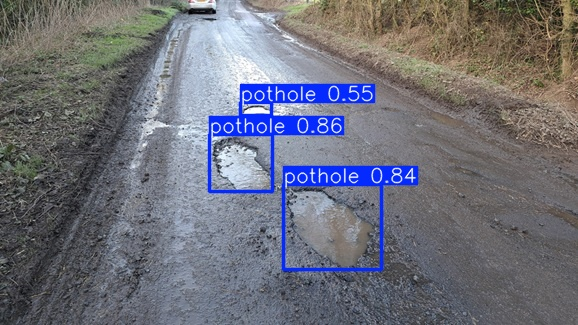

-


In [ ]:
from IPython.display import display, Image

print(f"Image: {IMG_YOLO_RESULT_ROMANIA}")
display(Image(filename=IMG_YOLO_RESULT_ROMANIA, height=300))
print("-")